In [11]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [12]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)

Dataset shape: (550068, 12)


In [13]:
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


First 5 rows:


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969



Data types:
User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Missing values:
User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

Duplicate rows: 0


In [14]:
# Basic statistical summary
print("Numerical summary:")
display(df.describe())

# Unique values in each column
print("\nUnique values:")
print(df.nunique())

Numerical summary:


,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000



Unique values:
User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category_1               20
Product_Category_2               17
Product_Category_3               15
Purchase                      18105
dtype: int64


In [15]:
# Check the different categories
print("Gender:")
print(df["Gender"].unique())

print("\nAge groups:")
print(df["Age"].unique())

print("\nCity categories:")
print(df["City_Category"].unique())

print("\nStay in current city:")
print(df["Stay_In_Current_City_Years"].unique())

Gender:
['F' 'M']

Age groups:
['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']

City categories:
['A' 'C' 'B']

Stay in current city:
['2' '4+' '3' '1' '0']


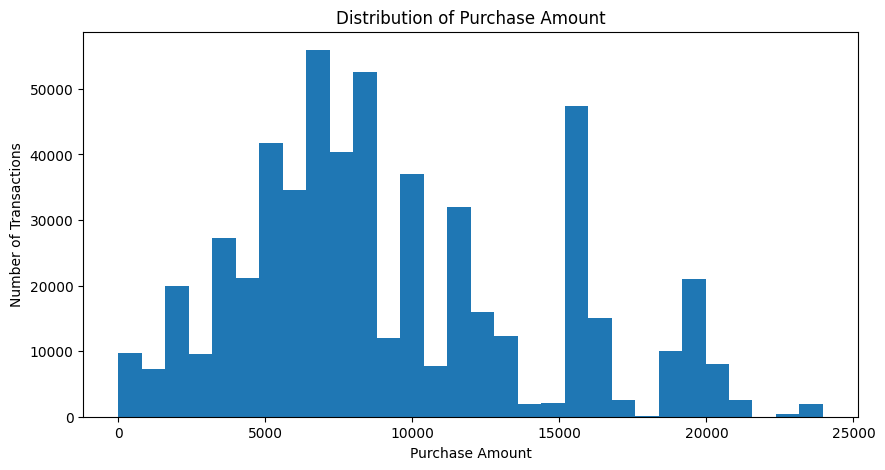

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["Purchase"], bins=30)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Transactions")

plt.show()

In [17]:
import matplotlib.pyplot as plt

gender_purchase = df.groupby("Gender")["Purchase"].agg(["count", "mean", "sum"])

print(gender_purchase)

         count         mean         sum
Gender                                 
F       135809  8734.565765  1186232642
M       414259  9437.526040  3909580100


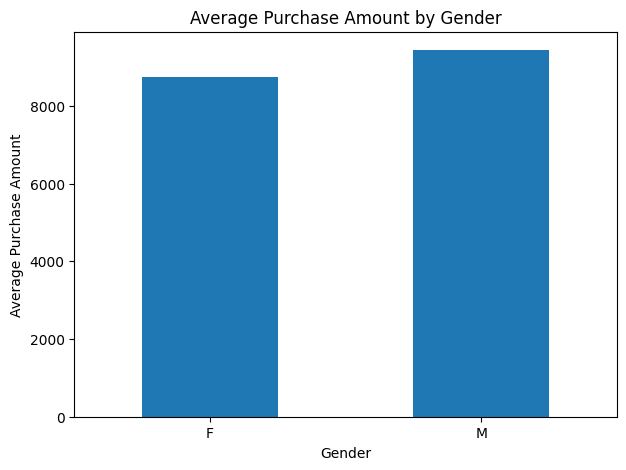

In [18]:
plt.figure(figsize=(7, 5))

df.groupby("Gender")["Purchase"].mean().plot(kind="bar")

plt.title("Average Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=0)

plt.show()

In [19]:
age_purchase = df.groupby("Age")["Purchase"].agg(
    transactions="count",
    average_purchase="mean",
    total_purchase="sum"
)

print(age_purchase)

       transactions  average_purchase  total_purchase
Age                                                  
0-17          15102       8933.464640       134913183
18-25         99660       9169.663606       913848675
26-35        219587       9252.690633      2031770578
36-45        110013       9331.350695      1026569884
46-50         45701       9208.625697       420843403
51-55         38501       9534.808031       367099644
55+           21504       9336.280459       200767375


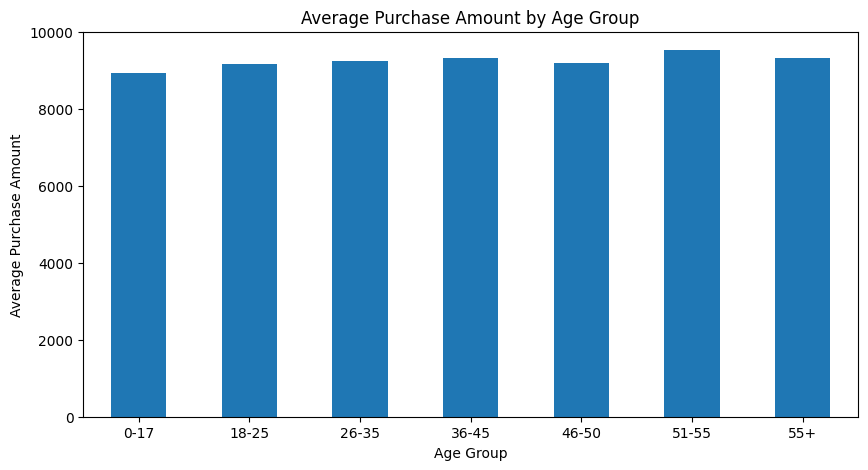

In [20]:
plt.figure(figsize=(10, 5))

age_purchase["average_purchase"].plot(kind="bar")

plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=0)

plt.show()

In [21]:
city_purchase = df.groupby("City_Category")["Purchase"].agg(
    transactions="count",
    average_purchase="mean",
    total_purchase="sum"
)

print(city_purchase)

               transactions  average_purchase  total_purchase
City_Category                                                
A                    147720       8911.939216      1316471661
B                    231173       9151.300563      2115533605
C                    171175       9719.920993      1663807476


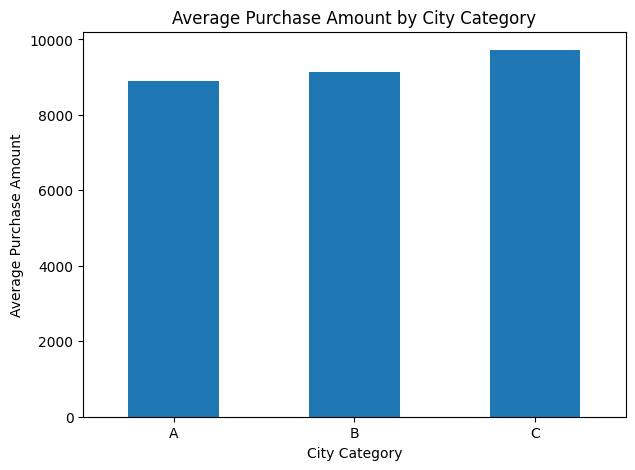

In [22]:
plt.figure(figsize=(7, 5))

city_purchase["average_purchase"].plot(kind="bar")

plt.title("Average Purchase Amount by City Category")
plt.xlabel("City Category")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=0)

plt.show()

In [23]:
category1 = df.groupby("Product_Category_1")["Purchase"].agg(
    transactions="count",
    average_purchase="mean",
    total_purchase="sum"
).sort_values("total_purchase", ascending=False)

print(category1)

                    transactions  average_purchase  total_purchase
Product_Category_1                                                
1                         140378      13606.218596      1910013754
5                         150933       6240.088178       941835229
8                         113925       7498.958078       854318799
6                          20466      15838.478550       324150302
2                          23864      11251.935384       268516186
3                          20213      10096.705734       204084713
16                          9828      14766.037037       145120612
11                         24287       4685.268456       113791115
10                          5125      19675.570927       100837301
15                          6290      14780.451828        92969042
7                           3721      16365.689600        60896731
4                          11753       2329.659491        27380488
14                          1523      13141.625739        2001

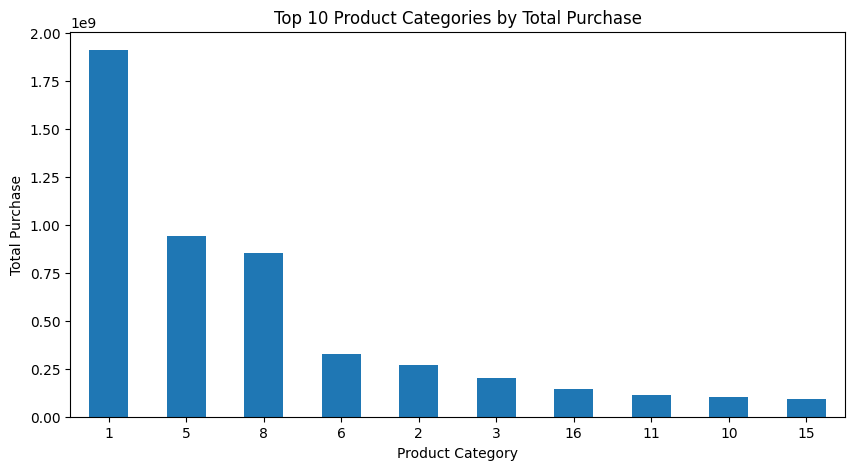

In [24]:
top_categories = category1.head(10)

plt.figure(figsize=(10, 5))

top_categories["total_purchase"].plot(kind="bar")

plt.title("Top 10 Product Categories by Total Purchase")
plt.xlabel("Product Category")
plt.ylabel("Total Purchase")
plt.xticks(rotation=0)

plt.show()

In [25]:
customer_purchase = df.groupby("User_ID")["Purchase"].agg(
    transactions="count",
    total_spend="sum",
    average_purchase="mean"
)

print(customer_purchase.head())

         transactions  total_spend  average_purchase
User_ID                                             
1000001            35       334093       9545.514286
1000002            77       810472      10525.610390
1000003            29       341635      11780.517241
1000004            14       206468      14747.714286
1000005           106       821001       7745.292453


In [26]:
print("Number of customers:", len(customer_purchase))

print("\nCustomer spending summary:")
display(customer_purchase.describe())

Number of customers: 5891

Customer spending summary:


,transactions,total_spend,average_purchase
count,5891.000000,5.891000e+03,5891.000000
mean,93.374300,8.650166e+05,9568.839914
std,107.190049,9.436445e+05,1890.087105
min,6.000000,4.668100e+04,2318.733333
25%,26.000000,2.376780e+05,8287.212366
50%,54.000000,5.212130e+05,9386.208333
75%,117.000000,1.119250e+06,10654.633199
max,1026.000000,1.053691e+07,18577.893617


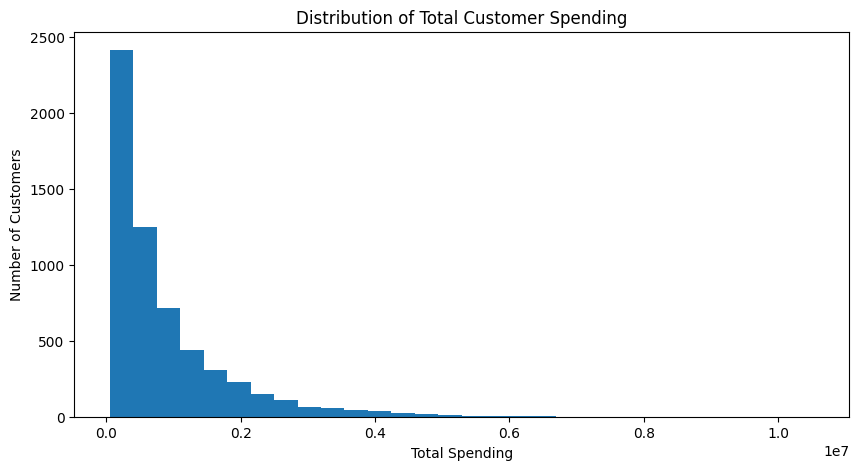

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(customer_purchase["total_spend"], bins=30)

plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

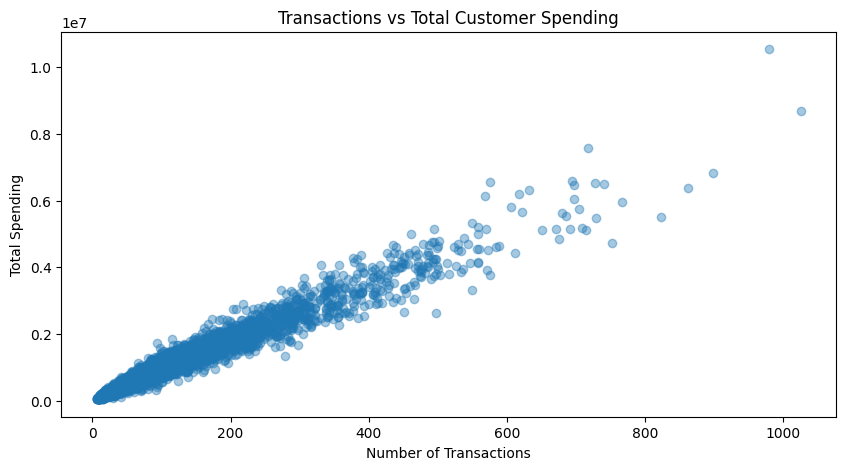

In [28]:
plt.figure(figsize=(10, 5))
plt.scatter(
    customer_purchase["transactions"],
    customer_purchase["total_spend"],
    alpha=0.4
)

plt.title("Transactions vs Total Customer Spending")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Spending")
plt.show()

In [29]:
numeric_cols = [
    "Occupation",
    "Marital_Status",
    "Product_Category_1",
    "Product_Category_2",
    "Product_Category_3",
    "Purchase"
]

correlation = df[numeric_cols].corr()

print(correlation["Purchase"].sort_values(ascending=False))

Purchase              1.000000
Occupation            0.020833
Marital_Status       -0.000463
Product_Category_3   -0.022006
Product_Category_2   -0.209918
Product_Category_1   -0.343703
Name: Purchase, dtype: float64


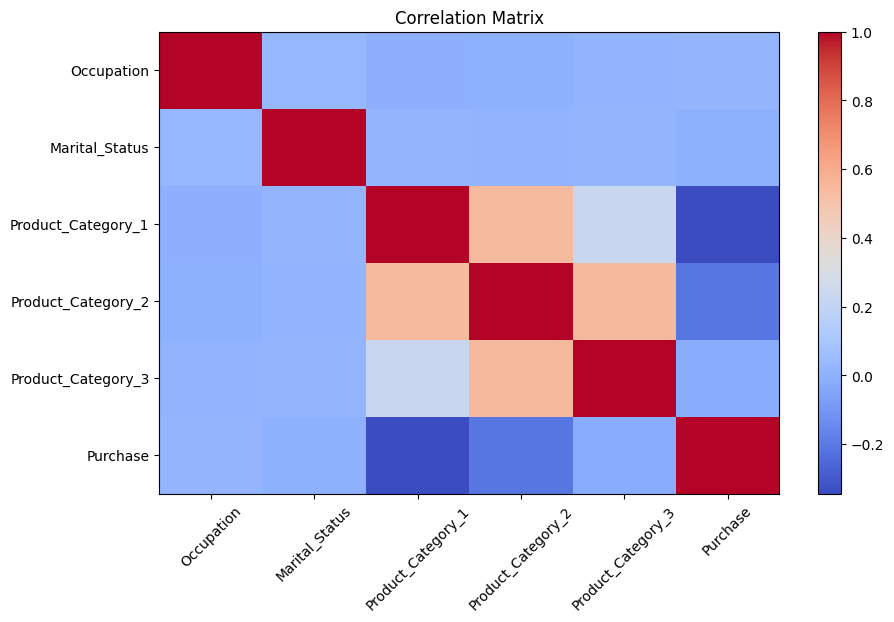

In [30]:
plt.figure(figsize=(10, 6))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")
plt.show()

In [31]:
print(correlation["Purchase"].sort_values(ascending=False))

Purchase              1.000000
Occupation            0.020833
Marital_Status       -0.000463
Product_Category_3   -0.022006
Product_Category_2   -0.209918
Product_Category_1   -0.343703
Name: Purchase, dtype: float64


In [32]:
print(df.dtypes)

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object


In [34]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(0)
df["Product_Category_3"] = df["Product_Category_3"].fillna(0)
print(df.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64


In [36]:
X = df.drop("Purchase", axis=1)
y = df["Purchase"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X = X.drop("User_ID", axis=1)

print(X.shape)

X shape: (550068, 11)
y shape: (550068,)
(550068, 10)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (440054, 10)
X_test: (110014, 10)
y_train: (440054,)
y_test: (110014,)


In [38]:
categorical_cols = [
    "Product_ID",
    "Gender",
    "Age",
    "City_Category",
    "Stay_In_Current_City_Years"
]

numerical_cols = [
    "Occupation",
    "Marital_Status",
    "Product_Category_1",
    "Product_Category_2",
    "Product_Category_3"
]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Product_ID', 'Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
Numerical columns: ['Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (440054, 3613)
Testing shape: (110014, 3613)


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 1978.0768078440544
RMSE: 2679.821244292898
R²  : 0.7141848893422862


In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 2175.484650836277
RMSE: 2891.9990635648132
R²  : 0.6671336987161064


In [43]:
numerical_cols_v2 = [
    "Occupation",
    "Marital_Status"
]

categorical_cols_v2 = [
    "Product_ID",
    "Gender",
    "Age",
    "City_Category",
    "Stay_In_Current_City_Years",
    "Product_Category_1",
    "Product_Category_2",
    "Product_Category_3"
]
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_v2),
        ("num", "passthrough", numerical_cols_v2)
    ]
)

X_train_v2 = preprocessor_v2.fit_transform(X_train)
X_test_v2 = preprocessor_v2.transform(X_test)

print("Training shape:", X_train_v2.shape)
print("Testing shape:", X_test_v2.shape)

Training shape: (440054, 3664)
Testing shape: (110014, 3664)


In [44]:
model_v2 = LinearRegression()

model_v2.fit(X_train_v2, y_train)

y_pred_v2 = model_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))
r2_v2 = r2_score(y_test, y_pred_v2)

print("Improved Linear Regression Results")
print("----------------------------------")
print("MAE :", mae_v2)
print("RMSE:", rmse_v2)
print("R²  :", r2_v2)

Improved Linear Regression Results
----------------------------------
MAE : 1977.678473604041
RMSE: 2679.006687370022
R²  : 0.7143586153284808


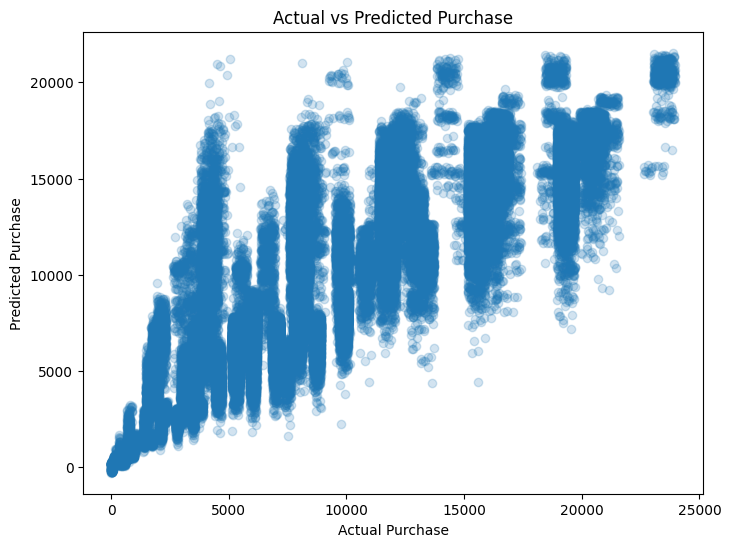

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_v2, alpha=0.2)

plt.xlabel("Actual Purchase")
plt.ylabel("Predicted Purchase")
plt.title("Actual vs Predicted Purchase")

plt.show()

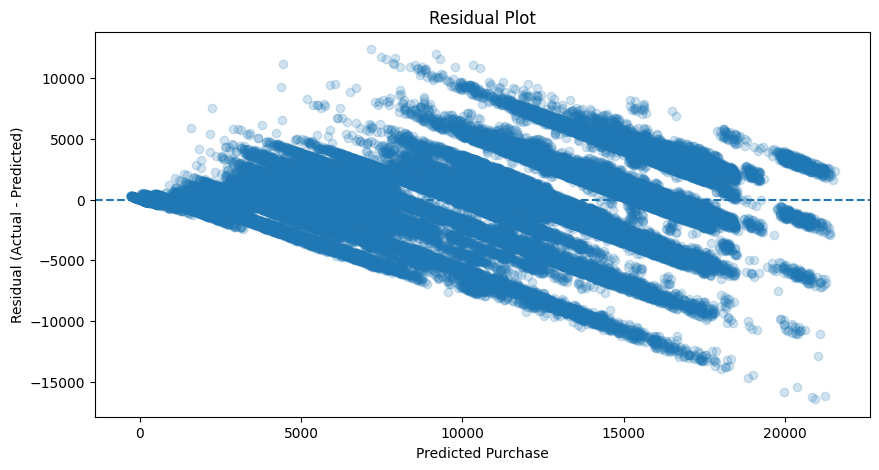

In [46]:
residuals = y_test - y_pred_v2

plt.figure(figsize=(10, 5))

plt.scatter(y_pred_v2, residuals, alpha=0.2)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Purchase")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [47]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Linear Regression v2"
    ],
    "MAE": [
        mae,
        rf_mae,
        mae_v2
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        rmse_v2
    ],
    "R2": [
        r2,
        rf_r2,
        r2_v2
    ]
})

print(results)

                  Model          MAE         RMSE        R2
0     Linear Regression  1978.076808  2679.821244  0.714185
1         Random Forest  2175.484651  2891.999064  0.667134
2  Linear Regression v2  1977.678474  2679.006687  0.714359


In [48]:
predictions_df = pd.DataFrame({
    "Actual_Purchase": y_test.values,
    "Predicted_Purchase": y_pred_v2
})

predictions_df["Error"] = (
    predictions_df["Actual_Purchase"]
    - predictions_df["Predicted_Purchase"]
)

predictions_df.head()

,Actual_Purchase,Predicted_Purchase,Error
0,19142,13344.410028,5797.589972
1,15513,16740.855511,-1227.855511
2,7802,7813.342686,-11.342686
3,15455,9951.187645,5503.812355
4,4492,13672.948200,-9180.948200


In [49]:
predictions_df.to_csv("purchase_predictions.csv", index=False)

print("Saved purchase_predictions.csv")

Saved purchase_predictions.csv
